# Learning to Infer Goals: Neural Inverse Planning on a Gridworld

## The Problem

An agent moves through an **8×8 gridworld** toward one of three candidate goals. As an **observer**, you watch the sequence of actions unfold — but you do not know which goal the agent is heading for.

**Inverse planning** is the task of inferring the agent's hidden goal from its observed behaviour. The key insight is that a goal-directed agent leaves evidence in its actions: an agent moving persistently north-west is probably not aiming for the south-east corner.

## Rational Agents

We model the agent as **Boltzmann-rational**: it selects actions proportionally to exponentiated Q-values toward its true goal $g$, scaled by a rationality parameter $\beta$:

$$\pi(a \mid s, g) \propto \exp(\beta \cdot Q^*(s, a, g))$$

Higher $\beta$ means more optimal behaviour; lower $\beta$ means noisier, harder-to-interpret actions. Given this model, the **exact Bayesian observer** can compute a posterior over goals after seeing $T$ actions:

$$P(g \mid a_{1:T}) \propto P(g) \prod_{t=1}^{T} \pi(a_t \mid s_t, g)$$

This exact posterior is our **ground truth** — what a perfect observer would compute.

## Our Approach: Learning to Infer Goals

Instead of computing the exact posterior at inference time, we train neural networks **directly from trajectory data** to approximate it. Each model observes the same sequence of actions (and optionally the grid state), and outputs a probability distribution over goals — trained to match the exact Bayesian posterior.

This tutorial is organised around three experiment questions:
- **Q1:** Can the models generalize to held-out trajectories from the same layout?
- **Q2:** Can models generalize across diverse random goal layouts — and if not, does scaling the data help?
- **Q3:** How does agent rationality affect inference difficulty?



## Models

All three models receive grid frames and the action sequence as input and output a probability distribution over goals at each timestep.

**Action-GRU** encodes each grid frame by flattening it through a small MLP, concatenates a previous-action embedding, then passes the sequence through a GRU. It sees the full spatial state but without any inductive bias for spatial structure.

**Conv-GRU** replaces the flat encoder with a convolutional network, giving the model an explicit spatial inductive bias. Otherwise the architecture is identical to Action-GRU. The key question is whether spatial structure in the encoding improves posterior quality.

**Goal-Conditioned Policy** takes a generative approach: instead of directly predicting the posterior, it learns the agent's policy $\hat{\pi}(a \mid s, g)$ conditioned on each candidate goal separately. At test time, it scores the observed sequence under each goal and applies Bayes' rule:

$$P(g_i \mid a_{1:T}) \propto \prod_{t=1}^{T} \hat{\pi}(a_t \mid s_t, g_i)$$

Unlike the GRU classifiers which are trained discriminatively end-to-end, this model mirrors the generative process — it asks which goal best explains the observed actions.

## Table of Contents

| # | Section | What it does |
|---|---|---|
| 1 | [Setup](#1.-Setup) | Imports, default task, GPU setting, helper functions |
| 2 | [Grid & Baseline Trajectory](#2.-Grid-&-Baseline-Trajectory) | Visualise the environment and one exact Bayesian posterior |
| 3 | [Scenario Walkthroughs](#3.-Scenario-Walkthroughs) | Build intuition with three hand-picked trajectories |
| 4 | [Question 1: Can models generalize to held-out trajectories?](#4.-Question-1:-Can-models-generalize-to-held-out-trajectories?) | Train once on the default layout and test on unseen trajectories |
| 5 | [Question 2: Can models generalize across diverse layouts and goals?](#5.-Question-2:-Can-models-generalize-across-diverse-layouts-and-goals?) | Test random-layout generalization, then ask whether more data helps |
| 6 | [Question 3: How does rationality change the task?](#6.-Question-3:-How-does-rationality-change-the-task?) | Vary $\beta$ on the default layout, matching Q1 |

---



## 1. Setup

We first import the project utilities, create the default 8×8 task (`beta=2.0`, three corner goals), and define two small helper functions so the experiment cells stay readable.

In [1]:
import os

# Restrict which physical GPUs this notebook can use.
# Examples: '1,3' => GPUs 1 and 3
GPU_IDS = '0,1,6,7'
os.environ['CUDA_VISIBLE_DEVICES'] = GPU_IDS

import numpy as np
import matplotlib.pyplot as plt
import torch
from dataclasses import replace
from pathlib import Path
from IPython.display import HTML, SVG, display

from inverse_planning.data import collect_dataset, encode_grid_frame, save_dataset, DatasetBundle
from inverse_planning.inference import (
    exact_goal_posterior,
    online_goal_posteriors,
    online_posteriors_from_goal_conditioned_action_probs,
    posterior_from_goal_conditioned_scores,
    score_goal_conditioned_policy,
)
from inverse_planning.memo_backend import MemoPolicyBackend
from inverse_planning.rnn_models import ModelFactory
from inverse_planning.simulate import sample_trajectory
from inverse_planning.task import GridworldTask, make_default_task
from inverse_planning.training import (
    TrainingConfig,
    build_classifier_loader,
    build_policy_loader,
    evaluate_classifier,
    evaluate_policy_model,
    train_classifier,
    train_policy_model,
)
from inverse_planning.visualize import render_gridworld_svg, render_trajectory_frames_html

# Shared tutorial settings.
HORIZON = 12
DEFAULT_TRAIN_EPISODES = 1024
DEFAULT_EVAL_EPISODES = 512
DEFAULT_EPOCHS = 8
BUDGET_EPOCHS = 5
DEFAULT_BATCH_SIZE = 256  # larger batches keep the GPU(s) busier than the old batch_size=64
EVAL_BATCH_SIZE = 512

# Default task.
task = make_default_task(beta=2.0)
memo_backend = MemoPolicyBackend(task)
memo_backend.build()
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
USE_DATA_PARALLEL = torch.cuda.is_available() and torch.cuda.device_count() > 1
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

print('task shape :', task.shape)
print('goals      :', task.goal_locs)
print('visible GPUs:', GPU_IDS or '(CPU only)')
print('device      :', device)
print('cuda devices:', torch.cuda.device_count())
print('data parallel:', USE_DATA_PARALLEL)


task shape : (8, 8)
goals      : ((0, 0), (0, 7), (7, 7))
visible GPUs: 0,1,6,7
device      : cuda:0
cuda devices: 4
data parallel: True


In [2]:
# Plot style used throughout the notebook.
MODEL_STYLES = {
    'action_gru':              {'label': 'Action-GRU',              'color': '#1b9e77', 'marker': 'o'},
    'conv_gru':                {'label': 'Conv-GRU',                'color': '#d95f02', 'marker': '^'},
    'goal_conditioned_policy': {'label': 'Goal-Conditioned Policy', 'color': '#7570b3', 'marker': 's'},
}
BETA_STYLES = {
    0.75: {'label': 'beta = 0.75', 'color': '#66a61e', 'marker': 'o'},
    1.5:  {'label': 'beta = 1.5',  'color': '#e6ab02', 'marker': '^'},
    3.0:  {'label': 'beta = 3.0',  'color': '#a6761d', 'marker': 's'},
}
LAYOUT_STYLES = {
    'corners': {'label': 'Corner Goals (default)', 'color': '#1f78b4'},
    'cluster': {'label': 'Central Cluster',        'color': '#33a02c'},
    'right':   {'label': 'Right-Side Spread',      'color': '#e31a1c'},
}
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.frameon': False,
})


In [3]:
def collect_and_save(name, task_i, backend_i, episodes, seed, horizon=HORIZON):
    """Collect one dataset from one fixed goal layout and save it under artifacts/."""
    bundle = collect_dataset(
        task_i,
        n_episodes=episodes,
        horizon=horizon,
        seed=seed,
        policy_backend=backend_i,
    )
    path = artifacts_dir / f'{name}.npz'
    save_dataset(path, bundle)
    unique_goals, counts = np.unique(bundle.goals, return_counts=True)
    print(f'{name:<28} {episodes:>5} episodes | goal counts: {dict(zip(unique_goals.tolist(), counts.tolist()))}')
    return bundle, np.load(path), path


def concatenate_bundles(bundles):
    """Merge several DatasetBundle objects that share the same shape and number of goals."""
    return DatasetBundle(
        grids=np.concatenate([b.grids for b in bundles], axis=0),
        positions=np.concatenate([b.positions for b in bundles], axis=0),
        actions=np.concatenate([b.actions for b in bundles], axis=0),
        goals=np.concatenate([b.goals for b in bundles], axis=0),
        final_posteriors=np.concatenate([b.final_posteriors for b in bundles], axis=0),
        online_posteriors=np.concatenate([b.online_posteriors for b in bundles], axis=0),
        goal_condition_inputs=np.concatenate([b.goal_condition_inputs for b in bundles], axis=0),
    )


def sample_goal_layouts(base_task, n_layouts, seed, n_goals=None):
    """Sample random goal layouts from non-wall cells, excluding the start cell."""
    rng = np.random.default_rng(seed)
    n_goals = base_task.n_goals if n_goals is None else n_goals
    open_cells = [tuple(cell) for cell in np.argwhere(~base_task.grid) if tuple(cell) != base_task.init_loc]
    layouts = []
    seen = set()
    while len(layouts) < n_layouts:
        indices = rng.choice(len(open_cells), size=n_goals, replace=False)
        layout = tuple(sorted(open_cells[i] for i in indices))
        if layout not in seen:
            layouts.append(layout)
            seen.add(layout)
    return layouts


def collect_random_layout_dataset(name, base_task, episodes, n_layouts, seed, horizon=HORIZON, beta=None):
    """Collect a dataset from randomly sampled goal layouts.

    Each layout is random; within each layout, the true goal for each episode is sampled
    by the trajectory simulator. Train and test calls should use different seeds so the
    held-out layouts are new.
    """
    beta = base_task.beta if beta is None else beta
    n_layouts = min(n_layouts, episodes)
    layouts = sample_goal_layouts(base_task, n_layouts=n_layouts, seed=seed)
    episode_counts = np.full(n_layouts, episodes // n_layouts, dtype=int)
    episode_counts[: episodes % n_layouts] += 1

    parts = []
    for layout_idx, (goal_locs, n_eps) in enumerate(zip(layouts, episode_counts)):
        layout_task = GridworldTask(grid=base_task.grid, init_loc=base_task.init_loc, goal_locs=goal_locs, beta=beta)
        layout_task.validate()
        backend = MemoPolicyBackend(layout_task)
        backend.build()
        part = collect_dataset(
            layout_task,
            n_episodes=int(n_eps),
            horizon=horizon,
            seed=seed + 10_000 + layout_idx,
            policy_backend=backend,
        )
        parts.append(part)

    bundle = concatenate_bundles(parts)
    path = artifacts_dir / f'{name}.npz'
    save_dataset(path, bundle)
    print(f'{name:<28} {episodes:>5} episodes | {n_layouts:>3} random layouts')
    return bundle, np.load(path), path, layouts



def maybe_parallel(model):
    """Use all visible GPUs for the model when more than one CUDA device is exposed."""
    if USE_DATA_PARALLEL:
        return torch.nn.DataParallel(model)
    return model


def save_model_state(model, path):
    """Save the underlying module when DataParallel is active."""
    stateful = model.module if isinstance(model, torch.nn.DataParallel) else model
    torch.save(stateful.state_dict(), path)


def materialize_lazy_model(model, train_npz, *, policy=False):
    """Run one tiny forward pass before DataParallel so LazyLinear parameters exist."""
    model = model.to(device)
    frames = torch.tensor(train_npz['grids'][:1], dtype=torch.float32, device=device)
    actions = np.asarray(train_npz['actions'][:1], dtype=np.int64)
    prev_actions = np.full_like(actions, task.n_actions)
    prev_actions[:, 1:] = actions[:, :-1]
    prev_actions_t = torch.tensor(prev_actions, dtype=torch.long, device=device)
    with torch.no_grad():
        if policy:
            goal_ids = torch.zeros(1, dtype=torch.long, device=device)
            model(frames, goal_ids, prev_actions_t)
        else:
            model(frames, prev_actions_t)
    return model


def train_model_suite(train_npz, eval_npz=None, epochs=DEFAULT_EPOCHS, prefix='model'):
    """Train the two discriminative GRUs and the goal-conditioned policy model."""
    n_actions = max(task.n_actions, int(train_npz['actions'].max()) + 1)
    if eval_npz is not None:
        n_actions = max(n_actions, int(eval_npz['actions'].max()) + 1)
    factory = ModelFactory(
        in_channels=train_npz['grids'].shape[2],
        n_actions=n_actions,
        n_goals=train_npz['final_posteriors'].shape[-1],
    )
    config = TrainingConfig(batch_size=DEFAULT_BATCH_SIZE, epochs=epochs, learning_rate=5e-4, device=device)
    runs = {}

    for variant in ['action_gru', 'conv_gru']:
        torch.manual_seed(0)
        model = materialize_lazy_model(factory.build_classifier(variant), train_npz, policy=False)
        model = maybe_parallel(model)
        losses = train_classifier(model, build_classifier_loader(train_npz, batch_size=config.batch_size, start_token=n_actions), config)
        metrics = evaluate_classifier(model, eval_npz, device=device, start_token=n_actions) if eval_npz is not None else {}
        runs[variant] = {'model': model, 'losses': losses, 'metrics': metrics}
        save_model_state(model, artifacts_dir / f'{prefix}_{variant}.pt')

    torch.manual_seed(0)
    policy_model = materialize_lazy_model(factory.build_policy_model(), train_npz, policy=True)
    policy_model = maybe_parallel(policy_model)
    policy_losses = train_policy_model(policy_model, build_policy_loader(train_npz, batch_size=config.batch_size, start_token=n_actions), config)
    policy_metrics = evaluate_policy_model(policy_model, eval_npz, device=device, batch_size=EVAL_BATCH_SIZE, start_token=n_actions) if eval_npz is not None else {}
    runs['goal_conditioned_policy'] = {'model': policy_model, 'losses': policy_losses, 'metrics': policy_metrics}
    save_model_state(policy_model, artifacts_dir / f'{prefix}_goal_conditioned_policy.pt')

    return runs


def print_run_table(runs):
    print(f"{'model':<28} {'final loss':>10} {'final-goal acc':>14} {'posterior KL':>12}")
    print('-' * 70)
    for name, run in runs.items():
        metrics = run.get('metrics', {})
        acc = metrics.get('final_goal_accuracy', float('nan'))
        kl = metrics.get('posterior_kl', float('nan'))
        print(f"{name:<28} {run['losses'][-1]:>10.4f} {acc:>14.4f} {kl:>12.4f}")



## 2. Grid & Baseline Trajectory

Visualise the default 8x8 gridworld and one memo-planned trajectory. The **exact observer posterior** computed from the Boltzmann policy is the gold standard every learned model aims to match.

initial location: (7, 0)
[[0 0 0 0 1 0 0 0]
 [0 1 1 0 1 0 1 0]
 [0 0 0 0 0 0 1 0]
 [1 1 0 1 1 0 0 0]
 [0 0 0 0 0 1 1 0]
 [0 1 1 1 0 0 0 0]
 [0 0 0 1 0 1 1 0]
 [0 1 0 0 0 0 0 0]]


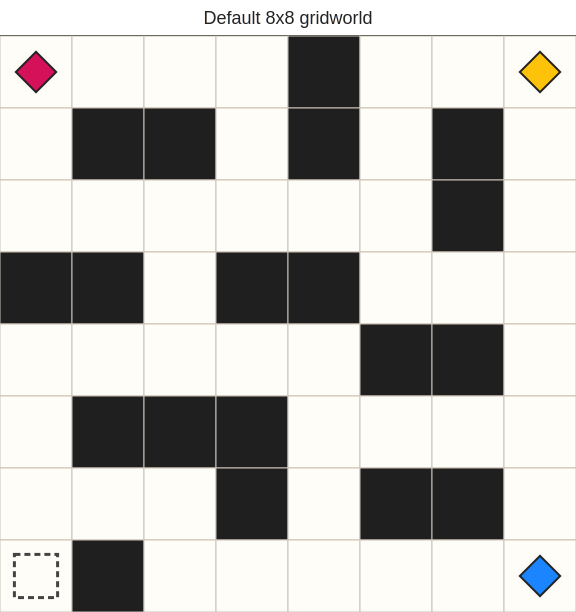

sampled goal index : 2
sampled actions    : [1, 0, 0, 4, 4, 2, 4, 4, 4, 4, 0, 4]
final exact posterior: [0.    0.005 0.995]


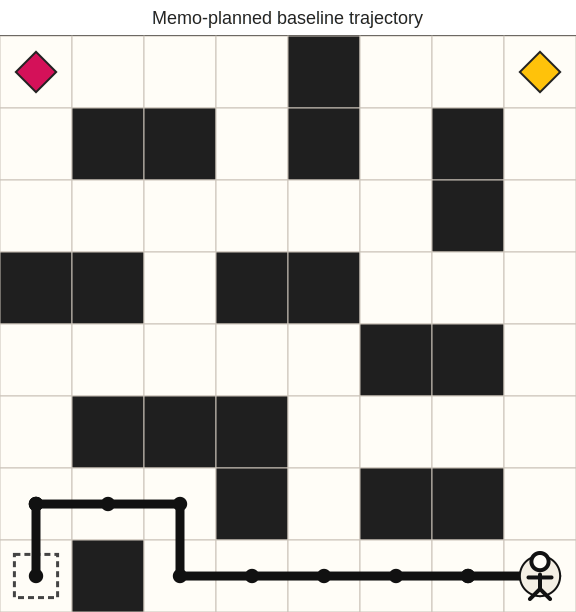

online exact posterior (rows = timesteps, cols = goals):
[[0.333 0.333 0.333]
 [0.333 0.333 0.333]
 [0.333 0.333 0.333]
 [0.018 0.018 0.965]
 [0.    0.01  0.99 ]
 [0.    0.01  0.99 ]
 [0.    0.01  0.99 ]
 [0.    0.01  0.99 ]
 [0.    0.005 0.995]
 [0.    0.005 0.995]
 [0.    0.005 0.995]
 [0.    0.005 0.995]]


In [4]:
print('initial location:', task.init_loc)
print(task.grid.astype(int))
display(SVG(render_gridworld_svg(task, cell_size=72, title='Default 8x8 gridworld')))

baseline = sample_trajectory(task, horizon=12, rng=np.random.default_rng(0), policy_backend=memo_backend)
baseline_posterior = exact_goal_posterior(task, baseline.action_indices, policy_backend=memo_backend)
baseline_online   = online_goal_posteriors(task, baseline.action_indices, policy_backend=memo_backend)

print('sampled goal index :', baseline.goal_index)
print('sampled actions    :', baseline.action_indices)
print('final exact posterior:', np.round(baseline_posterior, 3))
display(SVG(render_gridworld_svg(task, trajectory=baseline, cell_size=72, title='Memo-planned baseline trajectory')))
print('online exact posterior (rows = timesteps, cols = goals):')
print(np.round(baseline_online, 3))

## 3. Scenario Walkthroughs

Three hand-picked scenarios with fixed start and intended goal. Watching the online posterior update timestep-by-timestep gives intuition for how quickly the observer rules out alternative goals.

| Scenario | Start | True goal | Key insight |
|---|---|---|---|
| Northwest chase | (7,0) | 0 — (0,0) | Immediate northward commitment |
| Cross-map east goal | (4,0) | 1 — (0,7) | Long rightward drift disambiguates |
| Bottom-right commitment | (6,2) | 2 — (7,7) | Short horizon, fast posterior shift |

=== Northwest chase ===
  start=(7, 0)  goal=(0, 0)
  actions        : [1, 1, 1, 4, 4, 1, 0, 1, 3, 3, 1, 1]
  final posterior: [1. 0. 0.]


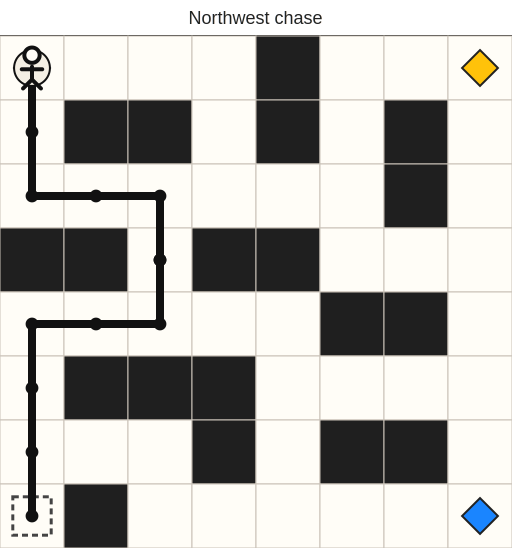

  online posterior (rows = timesteps):
[[0.333 0.333 0.333]
 [0.495 0.495 0.009]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.982 0.018 0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]]

=== Cross-map east goal ===
  start=(4, 0)  goal=(0, 7)
  actions        : [2, 1, 4, 0, 4, 1, 0, 1, 4, 4, 4, 1, 1, 4]
  final posterior: [0. 1. 0.]


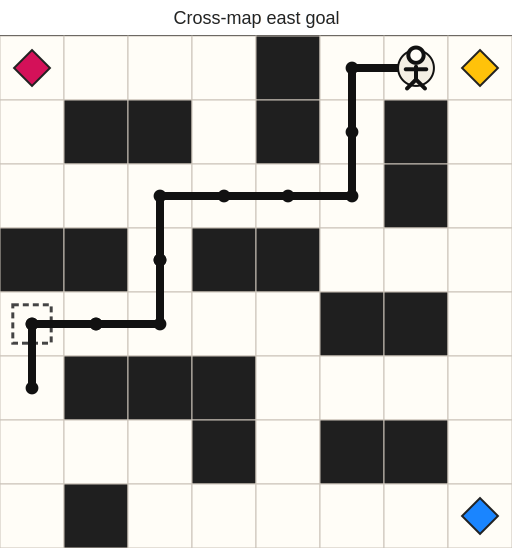

  online posterior (rows = timesteps):
[[0.032 0.032 0.937]
 [0.394 0.394 0.213]
 [0.436 0.436 0.127]
 [0.436 0.436 0.127]
 [0.436 0.436 0.127]
 [0.499 0.499 0.003]
 [0.499 0.499 0.003]
 [0.5   0.5   0.   ]
 [0.018 0.982 0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]]

=== Bottom-right commitment ===
  start=(6, 2)  goal=(7, 7)
  actions        : [2, 4, 4, 4, 4, 4, 0, 0, 0, 0]
  final posterior: [0. 0. 1.]


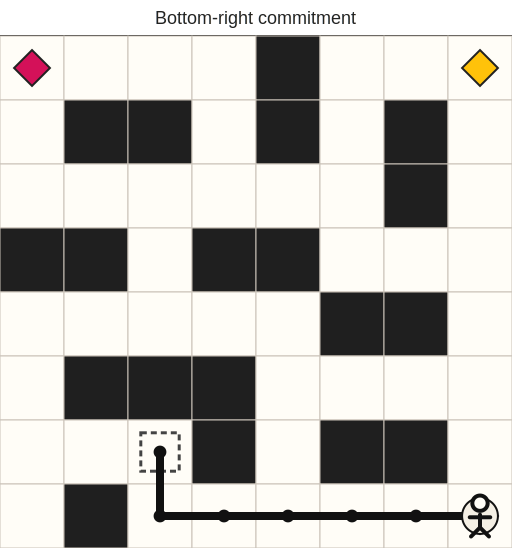

  online posterior (rows = timesteps):
[[0.009 0.495 0.495]
 [0.005 0.498 0.498]
 [0.005 0.498 0.498]
 [0.    0.352 0.648]
 [0.    0.352 0.648]
 [0.    0.352 0.648]
 [0.    0.075 0.925]
 [0.    0.012 0.988]
 [0.    0.002 0.998]
 [0.    0.    1.   ]]



In [5]:
scenario_specs = [
    {'name': 'Northwest chase',        'init_loc': (7, 0), 'goal_index': 0, 'horizon': 12, 'seed': 7},
    {'name': 'Cross-map east goal',    'init_loc': (4, 0), 'goal_index': 1, 'horizon': 14, 'seed': 11},
    {'name': 'Bottom-right commitment','init_loc': (6, 2), 'goal_index': 2, 'horizon': 10, 'seed': 17},
]

scenario_runs = []
for spec in scenario_specs:
    scenario_task = replace(task, init_loc=spec['init_loc'])
    scenario_task.validate()
    trajectory = sample_trajectory(
        scenario_task,
        horizon=spec['horizon'],
        rng=np.random.default_rng(spec['seed']),
        goal_index=spec['goal_index'],
        policy_backend=memo_backend,
    )
    posterior = exact_goal_posterior(scenario_task, trajectory.action_indices, policy_backend=memo_backend)
    online    = online_goal_posteriors(scenario_task, trajectory.action_indices, policy_backend=memo_backend)
    scenario_runs.append((spec, scenario_task, trajectory, posterior, online))

    print(f"=== {spec['name']} ===")
    print(f"  start={spec['init_loc']}  goal={scenario_task.goal_locs[spec['goal_index']]}")
    print('  actions        :', trajectory.action_indices)
    print('  final posterior:', np.round(posterior, 3))
    display(SVG(render_gridworld_svg(scenario_task, trajectory=trajectory, cell_size=64, title=spec['name'])))
    print('  online posterior (rows = timesteps):')
    print(np.round(online, 3))
    print()

## 4. Question 1: Can models generalize to held-out trajectories?

We start with the simplest generalization test: train on trajectories from the **default corner-goal layout**, then evaluate on fresh trajectories from that same layout.

To keep this tutorial lightweight, this question uses one reasonable budget (`1024` training episodes).

In [6]:
# One default training set and one held-out evaluation set for Q1.
default_train_bundle, default_train_npz, default_train_path = collect_and_save(
    'q1_default_train_1024', task, memo_backend, DEFAULT_TRAIN_EPISODES, seed=3
)
default_eval_bundle, default_eval_npz, default_eval_path = collect_and_save(
    'q1_default_eval_512', task, memo_backend, DEFAULT_EVAL_EPISODES, seed=99
)


q1_default_train_1024         1024 episodes | goal counts: {0: 348, 1: 351, 2: 325}


q1_default_eval_512            512 episodes | goal counts: {0: 172, 1: 156, 2: 184}


Now train all three model families. The target is the exact Bayesian online posterior, so **posterior KL** is the main metric: lower is better.


In [7]:
default_runs = train_model_suite(
    default_train_npz,
    eval_npz=default_eval_npz,
    epochs=DEFAULT_EPOCHS,
    prefix='q1_default',
)
print_run_table(default_runs)


model                        final loss final-goal acc posterior KL
----------------------------------------------------------------------
action_gru                       3.8928         0.8281       0.2570
conv_gru                         4.8230         0.8184       0.3165
goal_conditioned_policy          1.1392         0.9883       0.1768


A single held-out trajectory is useful for qualitative inspection. Each curve below is the model's belief in one candidate goal as more actions are observed.


held-out goal index         : 0
held-out actions            : [1, 1, 0, 1, 4, 4, 0, 1, 1, 3, 3, 4]
exact final posterior       : [0.982 0.018 0.   ]
action-gru final belief     : [0.621 0.253 0.125]
conv-gru final belief       : [0.549 0.236 0.215]
goal-cond. policy posterior : [0.721 0.267 0.012]


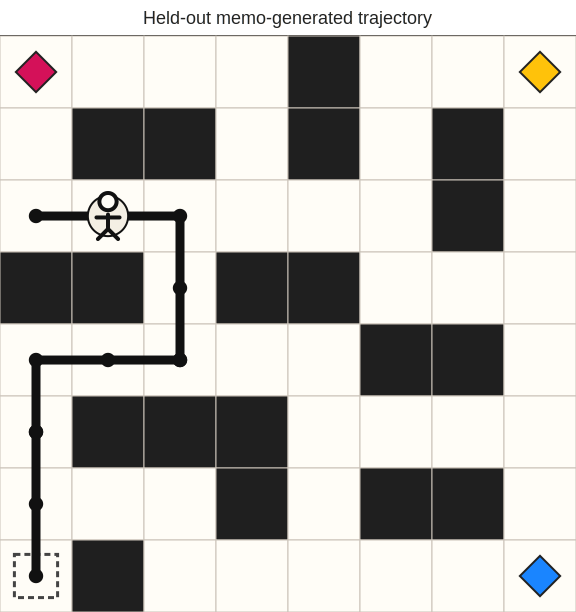

In [8]:
heldout = sample_trajectory(task, horizon=HORIZON, rng=np.random.default_rng(21), policy_backend=memo_backend)
heldout_exact = online_goal_posteriors(task, heldout.action_indices, policy_backend=memo_backend)

frames = np.stack(
    [encode_grid_frame(task, position=heldout.positions[step], step=step, horizon=len(heldout.action_indices))
     for step in range(len(heldout.action_indices))],
    axis=0,
)[None]
prev_actions = np.full((1, len(heldout.action_indices)), task.n_actions, dtype=np.int64)
prev_actions[0, 1:] = np.asarray(heldout.action_indices[:-1], dtype=np.int64)
action_indices = np.asarray(heldout.action_indices, dtype=np.int64)
frames_t = torch.tensor(frames, dtype=torch.float32, device=device)
prev_actions_t = torch.tensor(prev_actions, dtype=torch.long, device=device)

for run in default_runs.values():
    run['model'].eval().to(device)

with torch.no_grad():
    action_gru_out = default_runs['action_gru']['model'](frames_t, prev_actions_t)
    conv_gru_out = default_runs['conv_gru']['model'](frames_t, prev_actions_t)

action_gru_online = torch.softmax(action_gru_out['posterior_logits'], dim=-1)[0].detach().cpu().numpy()
conv_gru_online = torch.softmax(conv_gru_out['posterior_logits'], dim=-1)[0].detach().cpu().numpy()
action_gru_final = torch.softmax(action_gru_out['goal_logits'], dim=-1)[0].detach().cpu().numpy()
conv_gru_final = torch.softmax(conv_gru_out['goal_logits'], dim=-1)[0].detach().cpu().numpy()

policy_action_probs = []
policy_scores_list = []
with torch.no_grad():
    for goal_index in range(task.n_goals):
        goal_ids = torch.tensor([goal_index], dtype=torch.long, device=device)
        logits = default_runs['goal_conditioned_policy']['model'](frames_t, goal_ids, prev_actions_t)
        probs = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
        policy_action_probs.append(probs)
        policy_scores_list.append(score_goal_conditioned_policy(probs, action_indices))
policy_action_probs = np.asarray(policy_action_probs)
policy_posterior = posterior_from_goal_conditioned_scores(np.asarray(policy_scores_list))
policy_online = online_posteriors_from_goal_conditioned_action_probs(policy_action_probs, action_indices)

print('held-out goal index         :', heldout.goal_index)
print('held-out actions            :', heldout.action_indices)
print('exact final posterior       :', np.round(heldout_exact[-1], 3))
print('action-gru final belief     :', np.round(action_gru_final, 3))
print('conv-gru final belief       :', np.round(conv_gru_final, 3))
print('goal-cond. policy posterior :', np.round(policy_posterior, 3))
display(SVG(render_gridworld_svg(task, trajectory=heldout, cell_size=72, title='Held-out memo-generated trajectory')))


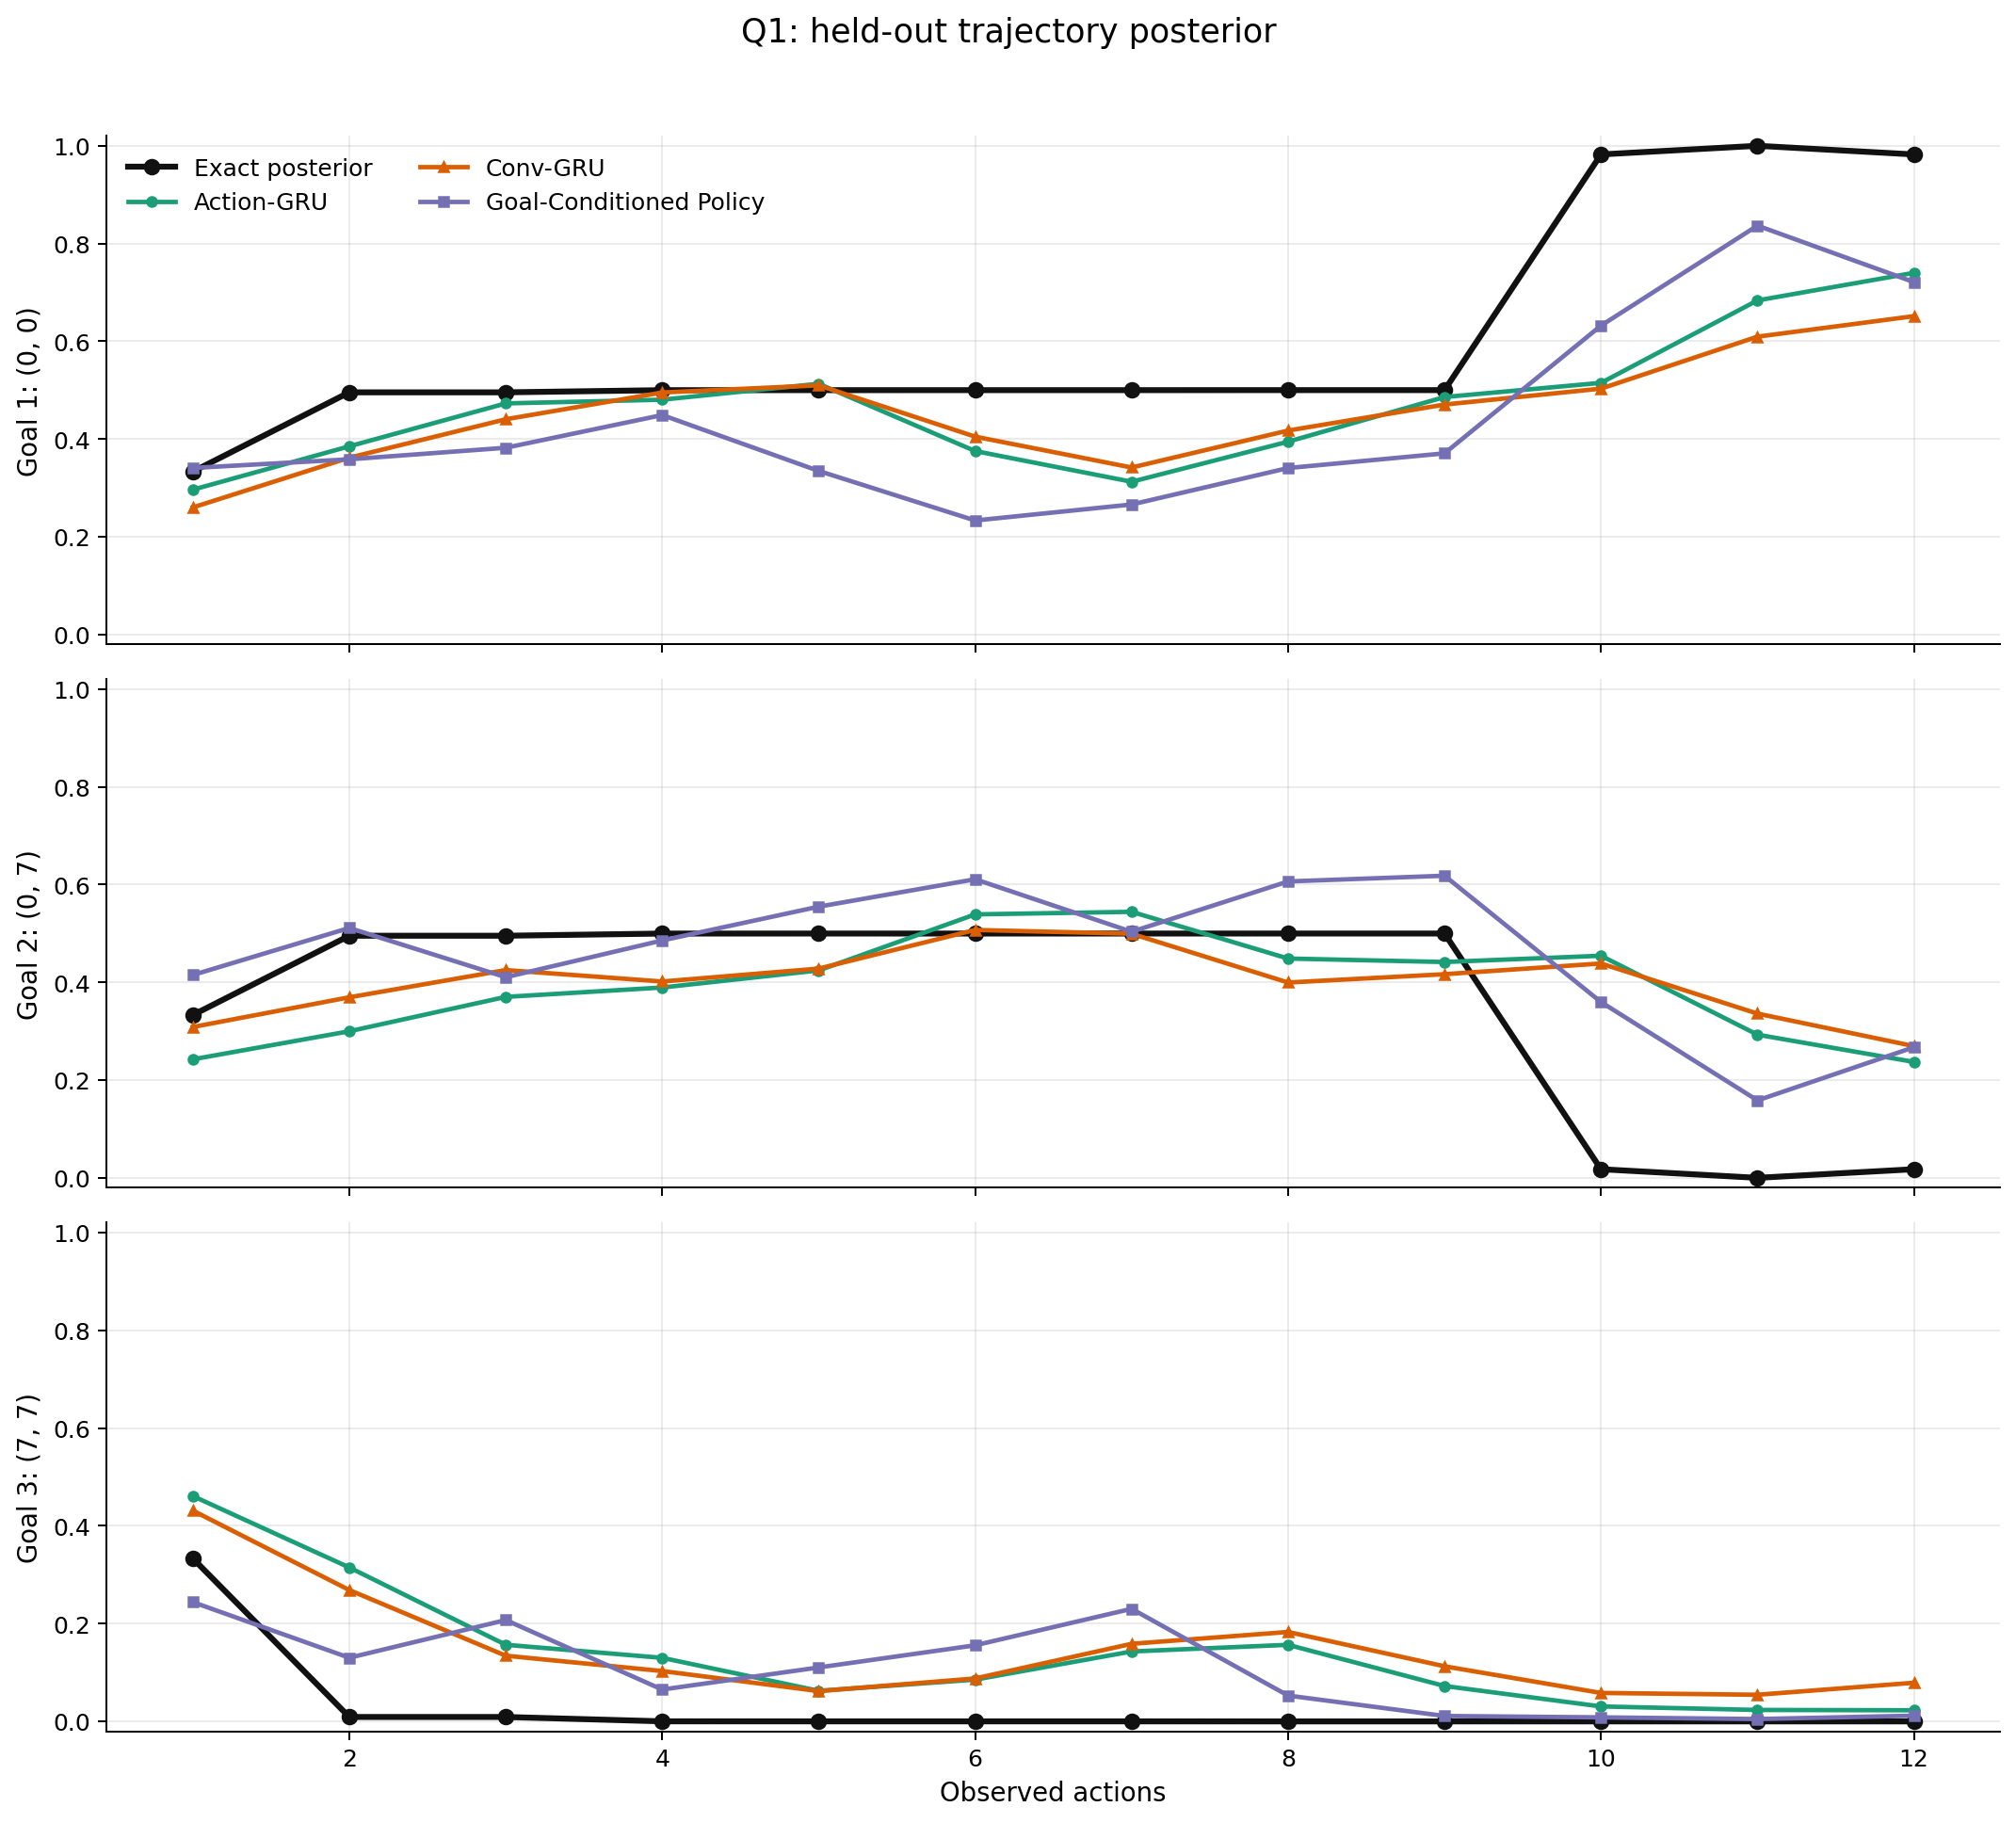

In [9]:
timesteps = np.arange(1, len(heldout.action_indices) + 1)
goal_labels = [f'Goal {idx + 1}: {goal}' for idx, goal in enumerate(task.goal_locs)]
fig, axes = plt.subplots(task.n_goals, 1, figsize=(12, 3.5 * task.n_goals), dpi=180, sharex=True)
if task.n_goals == 1:
    axes = [axes]

for goal_index, ax in enumerate(axes):
    ax.plot(timesteps, heldout_exact[:, goal_index], marker='o', linewidth=2.5, color='#111111', label='Exact posterior')
    for variant, series in [
        ('action_gru', action_gru_online[:, goal_index]),
        ('conv_gru', conv_gru_online[:, goal_index]),
        ('goal_conditioned_policy', policy_online[:, goal_index]),
    ]:
        style = MODEL_STYLES[variant]
        ax.plot(timesteps, series, marker=style['marker'], markersize=4, linewidth=1.9, color=style['color'], label=style['label'])
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel(goal_labels[goal_index])
    ax.grid(alpha=0.25)
    if goal_index == 0:
        ax.legend(loc='upper left', ncol=2)

axes[-1].set_xlabel('Observed actions')
fig.suptitle('Q1: held-out trajectory posterior', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


## 5. Question 2: Can models generalize across diverse layouts and goals?

Now we ask a harder generalization question: train on random candidate-goal layouts, then test on **different** random held-out layouts.

This setup may not work well with the default Q1-sized dataset because the model must learn to interpret arbitrary goal placements, not just one fixed corner layout. So after checking random-layout generalization, we immediately ask the natural follow-up: **can scaling to more training data help?**



In [10]:
q2_budget_specs = [
    {'name': 'q2_random_budget_1024',  'episodes':  1024, 'seed': 3},   # same order as Q1's default budget
    {'name': 'q2_random_budget_4096',  'episodes':  4096, 'seed': 5},
    {'name': 'q2_random_budget_8192',  'episodes':  8192, 'seed': 6},
    {'name': 'q2_random_budget_16384', 'episodes': 16384, 'seed': 7},
]
Q2_TRAIN_LAYOUTS = 32
Q2_EVAL_LAYOUTS = 32

_, q2_eval_npz, _, q2_eval_layouts = collect_random_layout_dataset(
    'q2_random_eval_512', task, episodes=512, n_layouts=Q2_EVAL_LAYOUTS, seed=900
)

q2_budget_registry = {}
for spec in q2_budget_specs:
    _, budget_npz, budget_path, budget_layouts = collect_random_layout_dataset(
        spec['name'], task, episodes=spec['episodes'], n_layouts=Q2_TRAIN_LAYOUTS, seed=spec['seed']
    )
    q2_budget_registry[spec['name']] = {
        'spec': spec,
        'npz': budget_npz,
        'path': budget_path,
        'layouts': budget_layouts,
    }



q2_random_eval_512             512 episodes |  32 random layouts


q2_random_budget_1024         1024 episodes |  32 random layouts


q2_random_budget_4096         4096 episodes |  32 random layouts


q2_random_budget_8192         8192 episodes |  32 random layouts


q2_random_budget_16384       16384 episodes |  32 random layouts


In [11]:
q2_scaling_results = []
q2_example_runs = None
q2_example_budget_name = q2_budget_specs[-1]['name']  # use the largest-data model for the trajectory walkthrough

for budget_name, entry in q2_budget_registry.items():
    runs = train_model_suite(
        entry['npz'],
        eval_npz=q2_eval_npz,
        epochs=BUDGET_EPOCHS,
        prefix=budget_name,
    )
    if budget_name == q2_example_budget_name:
        q2_example_runs = runs

    for variant, run in runs.items():
        metrics = run['metrics']
        q2_scaling_results.append({
            'budget_name': budget_name,
            'episodes': int(entry['spec']['episodes']),
            'variant': variant,
            'final_loss': float(run['losses'][-1]),
            'posterior_kl': metrics['posterior_kl'],
            'final_step_kl': metrics['posterior_kl_by_step'][-1],
            'posterior_kl_by_step': metrics['posterior_kl_by_step'],
        })

print(f"{'budget':>22} | {'model':<24} | mean KL | final-step KL")
print('-' * 74)
for row in q2_scaling_results:
    print(f"{row['budget_name']:>22} | {row['variant']:<24} | {row['posterior_kl']:.4f}  | {row['final_step_kl']:.4f}")



                budget | model                    | mean KL | final-step KL
--------------------------------------------------------------------------
 q2_random_budget_1024 | action_gru               | 0.5664  | 0.9676
 q2_random_budget_1024 | conv_gru                 | 0.5650  | 0.9661
 q2_random_budget_1024 | goal_conditioned_policy  | 0.5004  | 0.7939
 q2_random_budget_4096 | action_gru               | 0.4686  | 0.7446
 q2_random_budget_4096 | conv_gru                 | 0.4809  | 0.7784
 q2_random_budget_4096 | goal_conditioned_policy  | 0.4871  | 0.8105
 q2_random_budget_8192 | action_gru               | 0.4842  | 0.8287
 q2_random_budget_8192 | conv_gru                 | 0.4526  | 0.7234
 q2_random_budget_8192 | goal_conditioned_policy  | 0.4712  | 0.7930
q2_random_budget_16384 | action_gru               | 0.4706  | 0.8889
q2_random_budget_16384 | conv_gru                 | 0.3629  | 0.5614
q2_random_budget_16384 | goal_conditioned_policy  | 0.3635  | 0.6339


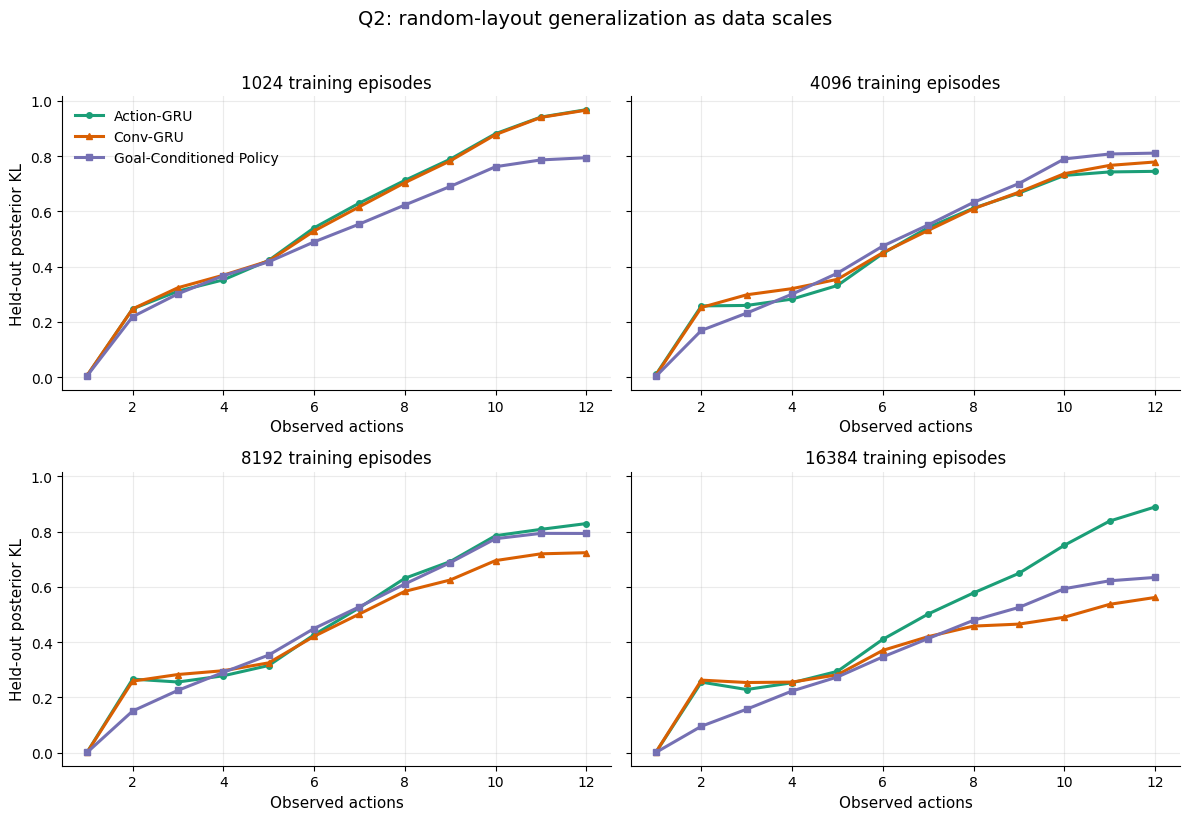

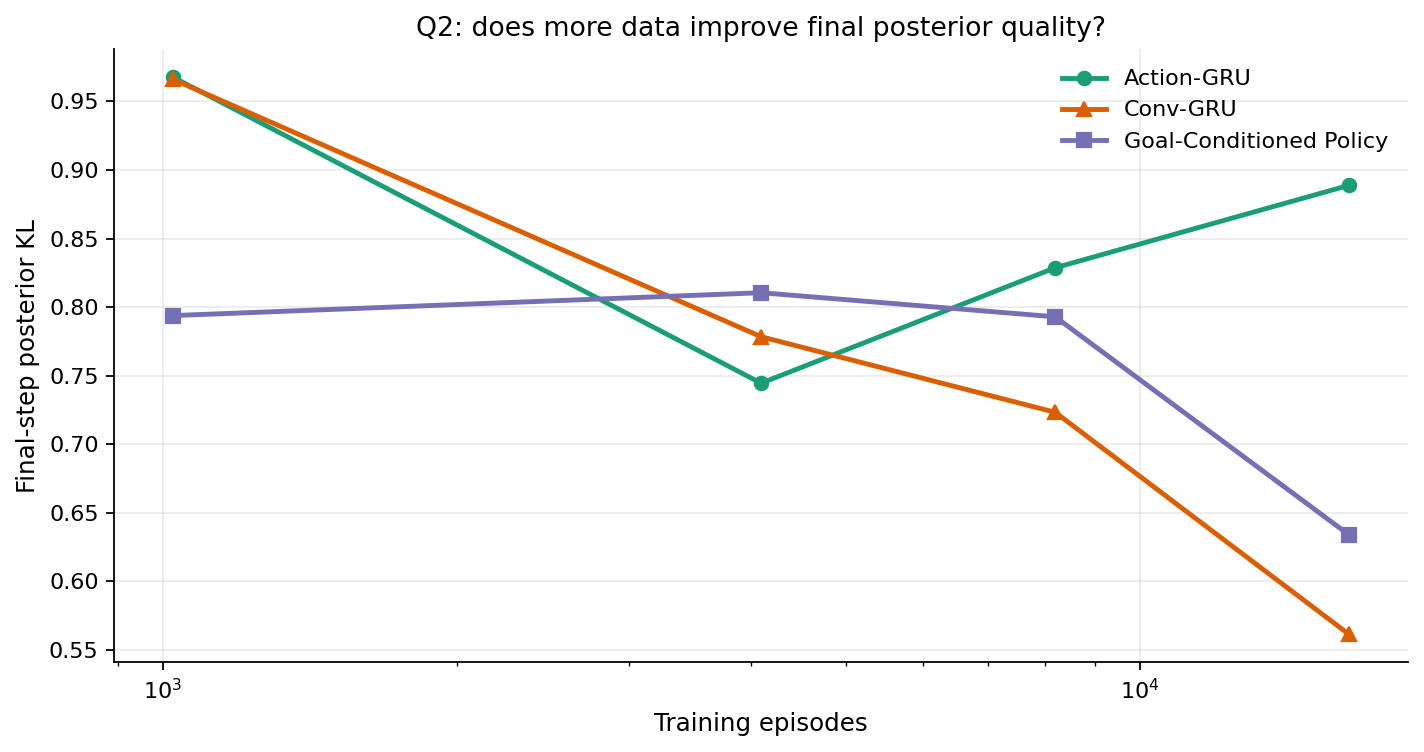

In [12]:
# Posterior KL over time for each training-data budget.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()
for ax, spec in zip(axes, q2_budget_specs):
    budget_name = spec['name']
    rows = [row for row in q2_scaling_results if row['budget_name'] == budget_name]
    for row in rows:
        style = MODEL_STYLES[row['variant']]
        timesteps = np.arange(1, len(row['posterior_kl_by_step']) + 1)
        ax.plot(timesteps, row['posterior_kl_by_step'], marker=style['marker'], markersize=4, linewidth=2.2, color=style['color'], label=style['label'])
    ax.set_title(f"{spec['episodes']} training episodes")
    ax.set_xlabel('Observed actions')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Held-out posterior KL')
axes[2].set_ylabel('Held-out posterior KL')
axes[0].legend(loc='upper left', ncol=1)
fig.suptitle('Q2: random-layout generalization as data scales', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# Final-step posterior quality as a direct function of training episodes.
fig, ax = plt.subplots(figsize=(9, 4.8), dpi=160)
for variant in ['action_gru', 'conv_gru', 'goal_conditioned_policy']:
    rows = sorted([r for r in q2_scaling_results if r['variant'] == variant], key=lambda r: r['episodes'])
    episodes = [r['episodes'] for r in rows]
    final_kls = [r['final_step_kl'] for r in rows]
    style = MODEL_STYLES[variant]
    ax.plot(episodes, final_kls, marker=style['marker'], linewidth=2.2, color=style['color'], label=style['label'])
ax.set_xscale('log')
ax.set_xlabel('Training episodes')
ax.set_ylabel('Final-step posterior KL')
ax.set_title('Q2: does more data improve final posterior quality?')
ax.grid(alpha=0.25)
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()



Finally, inspect one held-out trajectory from a random test layout using the largest-budget model suite. This mirrors the qualitative Q1 plot, but the layout was not part of the training layouts.



held-out random-layout goals : ((np.int64(0), np.int64(0)), (np.int64(4), np.int64(0)), (np.int64(4), np.int64(3)))
held-out goal index          : 0
held-out actions             : [1, 1, 1, 0, 4, 4, 1, 1, 3, 3, 1, 1]
exact final posterior        : [1. 0. 0.]


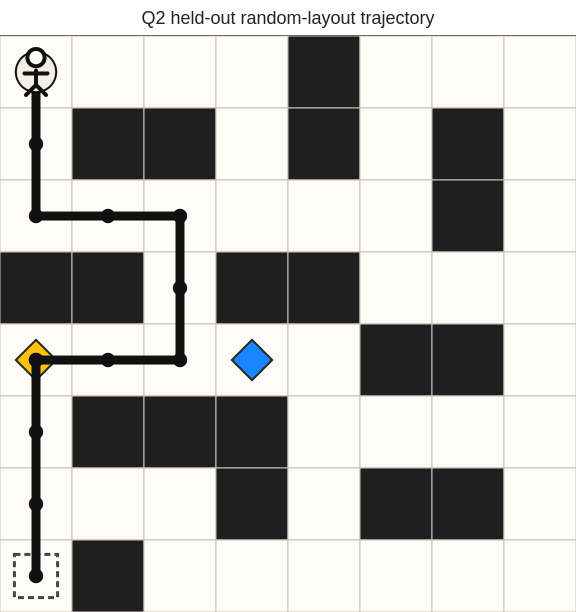

In [13]:
q2_demo_task = GridworldTask(
    grid=task.grid,
    init_loc=task.init_loc,
    goal_locs=q2_eval_layouts[0],
    beta=task.beta,
)
q2_demo_task.validate()
q2_demo_backend = MemoPolicyBackend(q2_demo_task)
q2_demo_backend.build()

q2_demo = sample_trajectory(q2_demo_task, horizon=HORIZON, rng=np.random.default_rng(42), policy_backend=q2_demo_backend)
q2_demo_exact = online_goal_posteriors(q2_demo_task, q2_demo.action_indices, policy_backend=q2_demo_backend)

q2_frames = np.stack(
    [encode_grid_frame(q2_demo_task, position=q2_demo.positions[step], step=step, horizon=len(q2_demo.action_indices))
     for step in range(len(q2_demo.action_indices))],
    axis=0,
)[None]
q2_prev_actions = np.full((1, len(q2_demo.action_indices)), q2_demo_task.n_actions, dtype=np.int64)
q2_prev_actions[0, 1:] = np.asarray(q2_demo.action_indices[:-1], dtype=np.int64)
q2_action_indices = np.asarray(q2_demo.action_indices, dtype=np.int64)
q2_frames_t = torch.tensor(q2_frames, dtype=torch.float32, device=device)
q2_prev_actions_t = torch.tensor(q2_prev_actions, dtype=torch.long, device=device)

for run in q2_example_runs.values():
    run['model'].eval().to(device)

with torch.no_grad():
    q2_action_gru_out = q2_example_runs['action_gru']['model'](q2_frames_t, q2_prev_actions_t)
    q2_conv_gru_out = q2_example_runs['conv_gru']['model'](q2_frames_t, q2_prev_actions_t)

q2_action_gru_online = torch.softmax(q2_action_gru_out['posterior_logits'], dim=-1)[0].detach().cpu().numpy()
q2_conv_gru_online = torch.softmax(q2_conv_gru_out['posterior_logits'], dim=-1)[0].detach().cpu().numpy()

q2_policy_action_probs = []
with torch.no_grad():
    for goal_index in range(q2_demo_task.n_goals):
        goal_ids = torch.tensor([goal_index], dtype=torch.long, device=device)
        logits = q2_example_runs['goal_conditioned_policy']['model'](q2_frames_t, goal_ids, q2_prev_actions_t)
        probs = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
        q2_policy_action_probs.append(probs)
q2_policy_action_probs = np.asarray(q2_policy_action_probs)
q2_policy_online = online_posteriors_from_goal_conditioned_action_probs(q2_policy_action_probs, q2_action_indices)

print('held-out random-layout goals :', q2_demo_task.goal_locs)
print('held-out goal index          :', q2_demo.goal_index)
print('held-out actions             :', q2_demo.action_indices)
print('exact final posterior        :', np.round(q2_demo_exact[-1], 3))
display(SVG(render_gridworld_svg(q2_demo_task, trajectory=q2_demo, cell_size=72, title='Q2 held-out random-layout trajectory')))



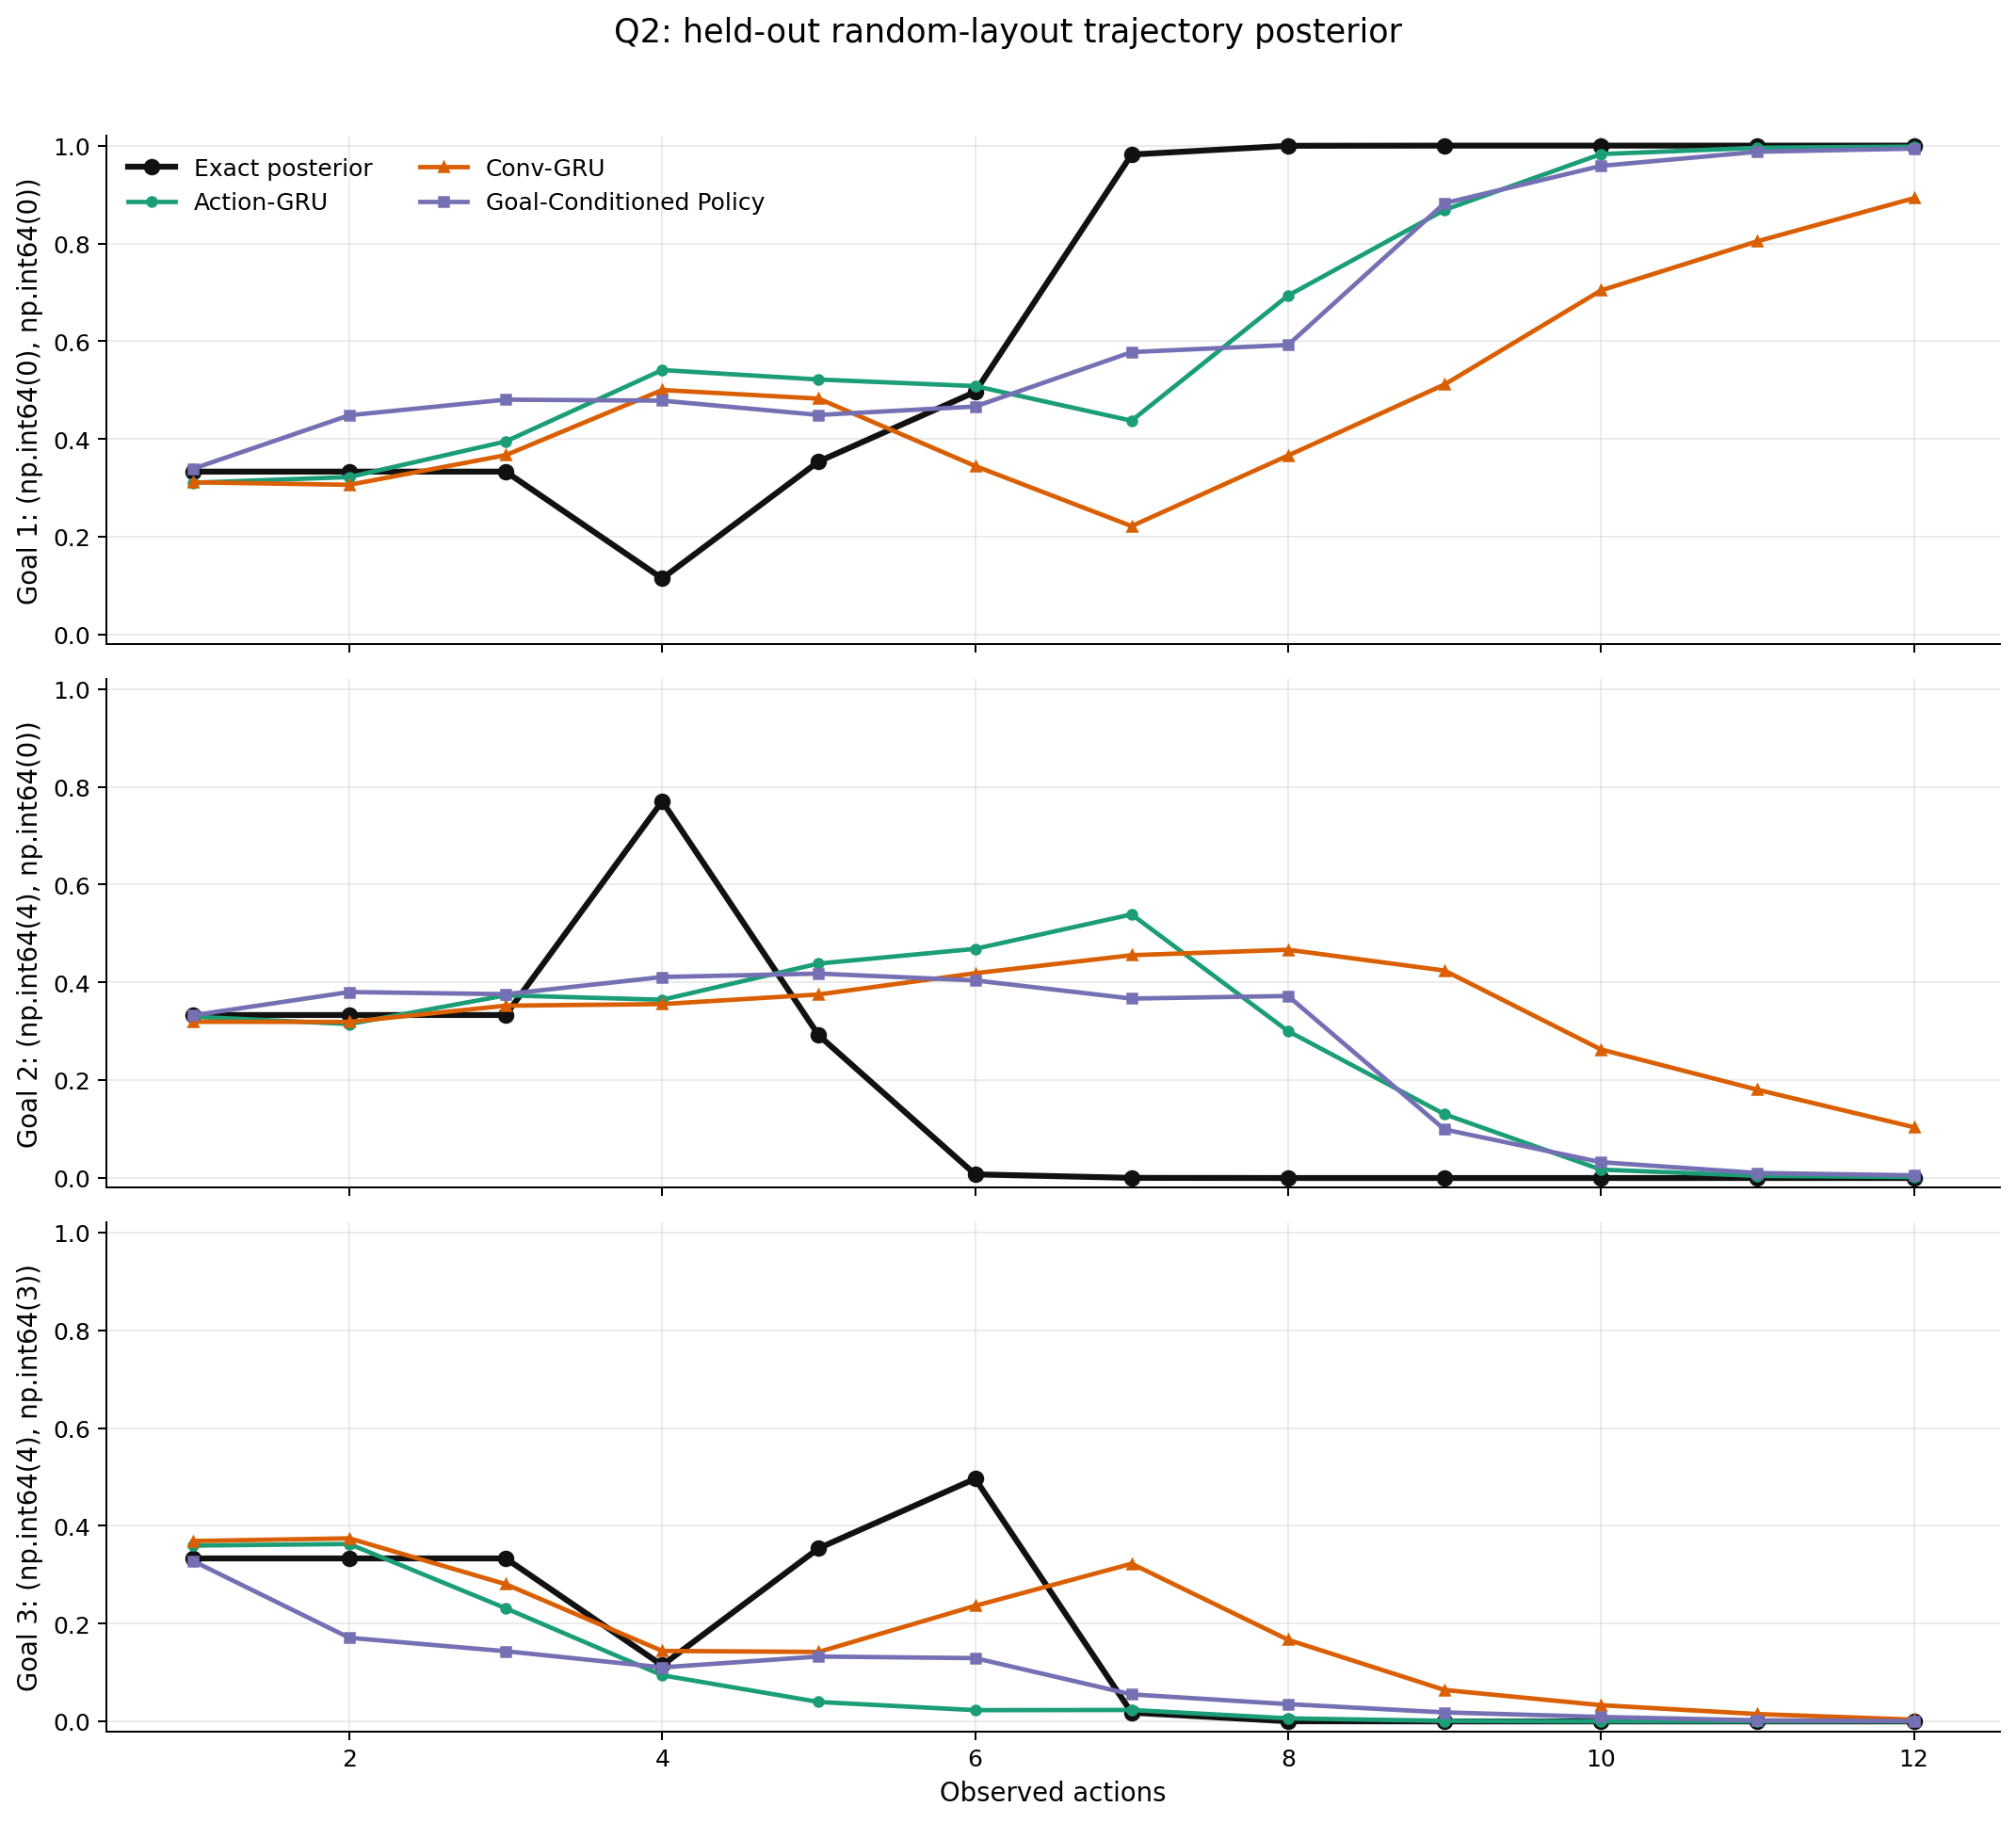

In [14]:
q2_timesteps = np.arange(1, len(q2_demo.action_indices) + 1)
q2_goal_labels = [f'Goal {idx + 1}: {goal}' for idx, goal in enumerate(q2_demo_task.goal_locs)]
fig, axes = plt.subplots(q2_demo_task.n_goals, 1, figsize=(12, 3.5 * q2_demo_task.n_goals), dpi=180, sharex=True)
if q2_demo_task.n_goals == 1:
    axes = [axes]

for goal_index, ax in enumerate(axes):
    ax.plot(q2_timesteps, q2_demo_exact[:, goal_index], marker='o', linewidth=2.5, color='#111111', label='Exact posterior')
    for variant, series in [
        ('action_gru', q2_action_gru_online[:, goal_index]),
        ('conv_gru', q2_conv_gru_online[:, goal_index]),
        ('goal_conditioned_policy', q2_policy_online[:, goal_index]),
    ]:
        style = MODEL_STYLES[variant]
        ax.plot(q2_timesteps, series, marker=style['marker'], markersize=4, linewidth=1.9, color=style['color'], label=style['label'])
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel(q2_goal_labels[goal_index])
    ax.grid(alpha=0.25)
    if goal_index == 0:
        ax.legend(loc='upper left', ncol=2)

axes[-1].set_xlabel('Observed actions')
fig.suptitle('Q2: held-out random-layout trajectory posterior', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()



## 6. Question 3: How does rationality change the task?

Q3 follows the same **fixed default-layout** setup as Q1, then varies only the Boltzmann rationality parameter $\beta$. Lower $\beta$ means noisier action choices, so the same amount of training data should make goal inference harder.

| $\beta$ | Behaviour | Expected inference |
|---|---|---|
| 0.75 | Very noisy | Slow disambiguation |
| 1.5  | Moderate | Medium |
| 3.0  | More optimal | Fast disambiguation |



In [15]:
beta_values = [0.75, 1.5, 3.0]
beta_train_episodes = 1024
beta_eval_episodes = 512
beta_results = []

for beta in beta_values:
    beta_task = make_default_task(beta=beta)
    beta_backend = MemoPolicyBackend(beta_task)
    beta_backend.build()
    beta_tag = str(beta).replace('.', 'p')

    _, beta_train_npz, _ = collect_and_save(
        f'q4_beta_{beta_tag}_train', beta_task, beta_backend, beta_train_episodes, seed=int(beta * 100)
    )
    _, beta_eval_npz, _ = collect_and_save(
        f'q4_beta_{beta_tag}_eval', beta_task, beta_backend, beta_eval_episodes, seed=1000 + int(beta * 100)
    )

    beta_runs = train_model_suite(
        beta_train_npz,
        eval_npz=beta_eval_npz,
        epochs=BUDGET_EPOCHS,
        prefix=f'q4_beta_{beta_tag}',
    )
    for variant, run in beta_runs.items():
        metrics = run['metrics']
        beta_results.append({
            'beta': beta,
            'variant': variant,
            'posterior_kl': metrics['posterior_kl'],
            'posterior_kl_by_step': metrics['posterior_kl_by_step'],
            'final_loss': float(run['losses'][-1]),
        })

print(f"{'beta':<8} | {'model':<24} | mean KL")
print('-' * 46)
for row in beta_results:
    print(f"{row['beta']:<8} | {row['variant']:<24} | {row['posterior_kl']:.4f}")



q4_beta_0p75_train            1024 episodes | goal counts: {0: 342, 1: 346, 2: 336}


q4_beta_0p75_eval              512 episodes | goal counts: {0: 162, 1: 157, 2: 193}


q4_beta_1p5_train             1024 episodes | goal counts: {0: 356, 1: 350, 2: 318}


q4_beta_1p5_eval               512 episodes | goal counts: {0: 161, 1: 177, 2: 174}


q4_beta_3p0_train             1024 episodes | goal counts: {0: 365, 1: 321, 2: 338}


q4_beta_3p0_eval               512 episodes | goal counts: {0: 167, 1: 178, 2: 167}


beta     | model                    | mean KL
----------------------------------------------
0.75     | action_gru               | 0.2312
0.75     | conv_gru                 | 0.2413
0.75     | goal_conditioned_policy  | 0.1480
1.5      | action_gru               | 0.4113
1.5      | conv_gru                 | 0.4414
1.5      | goal_conditioned_policy  | 0.2434
3.0      | action_gru               | 0.4992
3.0      | conv_gru                 | 0.5488
3.0      | goal_conditioned_policy  | 0.3028


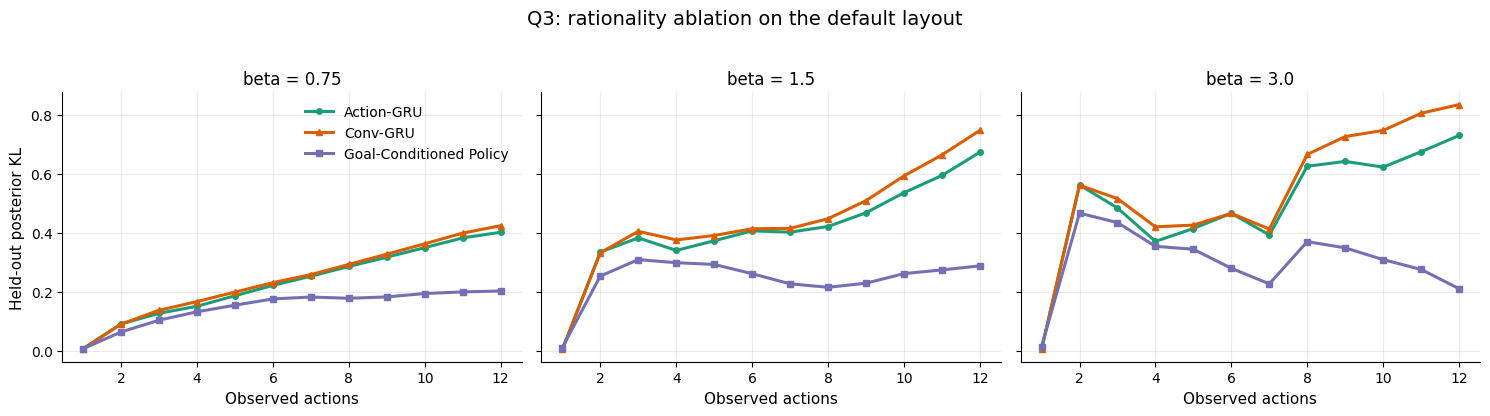

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, beta in zip(axes, beta_values):
    rows = [row for row in beta_results if row['beta'] == beta]
    for row in rows:
        style = MODEL_STYLES[row['variant']]
        timesteps = np.arange(1, len(row['posterior_kl_by_step']) + 1)
        ax.plot(timesteps, row['posterior_kl_by_step'], marker=style['marker'], markersize=4, linewidth=2.2, color=style['color'], label=style['label'])
    ax.set_title(BETA_STYLES[beta]['label'])
    ax.set_xlabel('Observed actions')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Held-out posterior KL')
axes[0].legend(loc='upper right')
fig.suptitle('Q3: rationality ablation on the default layout', y=1.03, fontsize=14)
fig.tight_layout()
plt.show()

